# Varying the Prompt: Effect on Accuracy

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import variations, RESULTS_ROOT_DIR, RESULTS_CSV_VARY_PROMPT, FIGURES_ROOT_DIR
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    create_result_df,
    load_risk_scores,
    prettify_model_name,
    load_results_overview,
    load_data_if_needed
)

In [3]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

FIGURES_PAPER_DIR = FIGURES_ROOT_DIR / "paper" / "vary-prompt"
TASKS = ["ACSIncome"]
print("tasks", TASKS)
MODELS = [
    "Qwen--Qwen2.5-7B-Instruct",
    "Qwen--Qwen2.5-72B-Instruct",
    "meta-llama--Meta-Llama-3-8B-Instruct",
    "meta-llama--Meta-Llama-3.3-70B-Instruct",
]
variations

tasks ['ACSIncome']


{'feature_order': ['default', 'rand 1', 'rand 2', 'rand 3', ' reversed'],
 'format': ['bullet', 'text', 'comma'],
 'connector': ['is', '=', ':'],
 'granularity': ['original', 'low']}

## Load available models and variations

In [4]:
try:
    data_all
except NameError:
    print("'data_all' not yet defined")
    data_all = load_data_if_needed(data=None, tasks=TASKS)
else:
    print("Already defined, update if needed.")
    data_all = load_data_if_needed(data=data_all, tasks=TASKS)

'data_all' not yet defined
ACSIncome


## Load predictions

In [5]:
num_shots = 0
threshold_fitted = True

df = load_results_overview(
    num_shots=num_shots, threshold_fitted=threshold_fitted, same_prompt=False
)
df = df[df["task"].isin(TASKS)]
df = df[df["model"].isin(MODELS)]
df.shape

(383, 15)

In [6]:
try:
    assert set(TASKS).issubset(
        set(df["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df['task'].unique())} "
except AssertionError:
    TASKS = list(df["task"].unique())
    logging.warning(f"Reduced TASKS to available tasks: {TASKS}")

In [7]:
df.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,balanced_accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
0,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.164835,0.761706,0.769047,175002779,0,text,=,low,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
1,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.148014,0.776888,0.772921,1344084919,0,bullet,is,original,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
2,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003172,0.766957,0.779197,3156286684,0,text,is,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
3,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003183,0.772761,0.776203,2985942201,0,bullet,:,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
4,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.007574,0.779946,0.777026,1338756957,0,bullet,is,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...


In [8]:
risk_scores = (
    df["predictions_path"]
    .apply(load_risk_scores)
    .apply(lambda x: x.squeeze())
    .add_prefix("score_")
)
risk_scores.head()
df_with_riskscores = pd.concat([df, risk_scores], axis=1)
print(df_with_riskscores.shape)
display(df_with_riskscores.head())

df_with_predictions = df_with_riskscores.copy()
model_wise_thresholds = df_with_predictions["threshold"]
df_with_predictions.update(
    df_with_predictions.filter(like="score_").apply(
        lambda col: (col >= model_wise_thresholds).astype(int)
    )
)

(383, 166465)


,task,model,is_inst,threshold_fitted,threshold,accuracy,balanced_accuracy,bench_hash,num_shots,prompt_format,...,score_944636,score_675237,score_926337,score_2205318,score_3164791,score_43637,score_2494279,score_2989522,score_688458,score_1778641
0,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.164835,0.761706,0.769047,175002779,0,text,...,0.817610,0.000203,0.999445,0.067620,0.004594,0.593750,0.000432,0.000710,0.998831,0.992433
1,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.148014,0.776888,0.772921,1344084919,0,bullet,...,0.106689,0.000140,0.999860,0.018028,0.984146,0.851960,0.000204,0.000159,0.997210,0.182796
2,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003172,0.766957,0.779197,3156286684,0,text,...,0.001699,0.000066,0.999821,0.000380,0.852130,0.561404,0.000123,0.000159,0.998678,0.133127
3,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003183,0.772761,0.776203,2985942201,0,bullet,...,0.000488,0.000066,0.999877,0.000488,0.817727,0.777349,0.000096,0.000096,0.999089,0.042092
4,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.007574,0.779946,0.777026,1338756957,0,bullet,...,0.000908,0.000058,0.999891,0.000553,0.852137,0.678851,0.000096,0.000109,0.998967,0.182320


In [9]:
mask = df_with_predictions['task']=='ACSIncome'
top_acc = df_with_predictions[mask]['accuracy'].max()
eps = 0.05
mask &= df_with_predictions['accuracy']>= top_acc - eps
df_with_predictions[mask].sort_values(by='accuracy', ascending=False)

,task,model,is_inst,threshold_fitted,threshold,accuracy,balanced_accuracy,bench_hash,num_shots,prompt_format,...,score_944636,score_675237,score_926337,score_2205318,score_3164791,score_43637,score_2494279,score_2989522,score_688458,score_1778641
645,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999411,0.789462,0.782966,3953032439,0,bullet,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
652,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999411,0.789462,0.782966,3212939787,0,bullet,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
823,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999541,0.785095,0.775657,2982431102,0,bullet,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
12,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.294643,0.784506,0.774093,1751177837,0,bullet,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
707,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999447,0.784308,0.780452,86690888,0,bullet,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,1,0.946479,0.741196,0.761155,3047852308,0,text,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
638,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.998965,0.741087,0.765067,3270947147,0,comma,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
341,ACSIncome,Qwen--Qwen2.5-7B-Instruct,1,1,0.020345,0.740108,0.755431,2720610729,0,bullet,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
359,ACSIncome,Qwen--Qwen2.5-7B-Instruct,1,1,0.053448,0.739760,0.745946,2097281108,0,comma,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0


## Aggregate Level: Check accuracy

In [10]:
models_to_plot = MODELS
models_to_plot = sorted(models_to_plot, key=get_size_and_it)

### Scatter Plot: Fix one variation, others default

prompt_feature_order 23
Qwen--Qwen2.5-7B-Instruct
Qwen 2.5 7B (it) 	 0.75	0.005	0.031
meta-llama--Meta-Llama-3-8B-Instruct
Llama 3 8B (it)  	 0.76	0.002	0.015
meta-llama--Meta-Llama-3.3-70B-Instruct
Llama 3.3 70B (it)	 0.78	0.004	0.023
Qwen--Qwen2.5-72B-Instruct
Qwen 2.5 72B (it)	 0.77	0.004	0.024
prompt_format 15
Qwen--Qwen2.5-7B-Instruct
Qwen 2.5 7B (it) 	 0.76	0.003	0.011
meta-llama--Meta-Llama-3-8B-Instruct
Llama 3 8B (it)  	 0.76	0.004	0.025
meta-llama--Meta-Llama-3.3-70B-Instruct
Llama 3.3 70B (it)	 0.78	0.002	0.012
Qwen--Qwen2.5-72B-Instruct
Qwen 2.5 72B (it)	 0.77	0.003	0.013
prompt_connector 14
Qwen--Qwen2.5-7B-Instruct
Qwen 2.5 7B (it) 	 0.75	0.008	0.029
meta-llama--Meta-Llama-3-8B-Instruct
Llama 3 8B (it)  	 0.75	0.006	0.029
meta-llama--Meta-Llama-3.3-70B-Instruct
Llama 3.3 70B (it)	 0.79	0.002	0.010
Qwen--Qwen2.5-72B-Instruct
Qwen 2.5 72B (it)	 0.78	0.002	0.007
prompt_granularity 11
Qwen--Qwen2.5-7B-Instruct
Qwen 2.5 7B (it) 	 0.76	0.005	0.015
meta-llama--Meta-Llama-3-8B-In

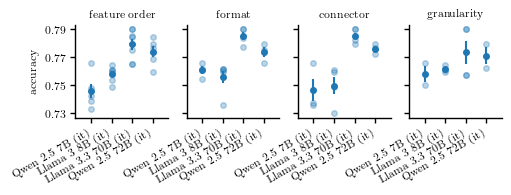

In [11]:
eps = 0.05
max_acc_acsincome = 0.789462
plot_all = False
default_cond = {
    "prompt_feature_order": variations["feature_order"][0],
    "prompt_format": "bullet",
    "prompt_connector": "is",
    "prompt_granularity": "original",
}
# select all individuals where some key is the default value
all_default_accs = df.loc[
    list(
        set.intersection(
            *[
                set(df[df[key] == val].index)
                for key, val in default_cond.items()
            ]
        )
    )
][["model", "accuracy"]]

default_width = plt.rcParams['figure.figsize'][0]
# Set custom height
custom_height = 1.2 #plt.rcParams['figure.figsize'][1]


# Plot
fig, axs = plt.subplots(
    1,
    len(variations.keys())+int(plot_all),
    figsize=(default_width, custom_height),
    # , constrained_layout=True,
    sharey=True
)

y_max = 0
y_min = 1
for v, vary_variable in enumerate(list(default_cond.keys()) + (['all combinations'] if plot_all else [])):
    # select all individuals where all but one (vary_variable) are set to the default value
    df_vary_one = df.loc[
        list(
            set.intersection(
                *[
                    set(df[df[key] == val].index)
                    for key, val in default_cond.items()
                    if key != vary_variable
                ]
            )
        )
    ]
    alpha=0.3
    if vary_variable == 'all combinations':
        #mask = df['accuracy'] >= max_acc_acsincome - eps
        df_vary_one = df#[mask]
        alpha=0.1

    print(vary_variable, df_vary_one.shape[0])    
    for i, model in enumerate(models_to_plot):
        print(model)
        accs = df_vary_one[df_vary_one["model"] == model]["accuracy"].values
        # display(df_vary_one[df_vary_one["model"] == model]["accuracy"].values)
        mean = accs.mean()
        stderr = accs.std() / np.sqrt(len(accs))  # or standard error?
        print(
            f"{prettify_model_name(key_to_model(model)):17}\t {mean:.2f}\t{stderr:.3f}\t{accs.max()-accs.min():.3f}"
        )
        if accs.max() > y_max:
            y_max = accs.max()
        if accs.min() < y_min:
            y_min = accs.min()

        default_acc = all_default_accs[all_default_accs["model"] == model][
            "accuracy"
        ].mean()
        axs[v].errorbar(i, mean, yerr=stderr, ls="None", color="C0", label="mean")
        axs[v].scatter(i, mean, color="C0")
        axs[v].scatter([i] * len(accs), accs, color="C0", alpha=alpha)
        axs[v].set_xmargin(1 / len(models_to_plot))
    axs[v].set_xticks(
        np.arange(len(models_to_plot)),
        [prettify_model_name(key_to_model(model)) for model in models_to_plot],
        rotation=30,
        ha="right",
        va='top'
    )


    axs[v].set_title(vary_variable.replace("prompt_", " ").replace("_", " "))
axs[0].set_ylabel("accuracy")
yticks = np.linspace(y_min, y_max, num=4)
axs[0].set_yticks(yticks, [f"{tick:.2}" for tick in yticks])


file_name = "".join(
    [
        f"performance-{num_shots}-shot-fix-one-default-rest-scatter",
        "_tresh_fitted" if threshold_fitted == 1 else "",
    ]
)

for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()